# Imports

In [75]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# For IterativeImputer with a regressor
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

import joblib

# Load Data

In [76]:
df = pd.read_csv("/content/drive/MyDrive/colab_notebooks/gita/data/original/train.csv")

os.makedirs("processed_data", exist_ok=True)

# EDA

In [77]:
df.shape

(891, 12)

In [78]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [79]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
740,741,1,1,"Hawksford, Mr. Walter James",male,NaN,0,0,16988,30.0000,D45,S
833,834,0,3,"Augustsson, Mr. Albert",male,23.0,0,0,347468,7.8542,NaN,S
370,371,1,1,"Harder, Mr. George Achilles",male,25.0,1,0,11765,55.4417,E50,C


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [81]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [82]:
df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [83]:
df.duplicated().sum()

0

In [84]:
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0


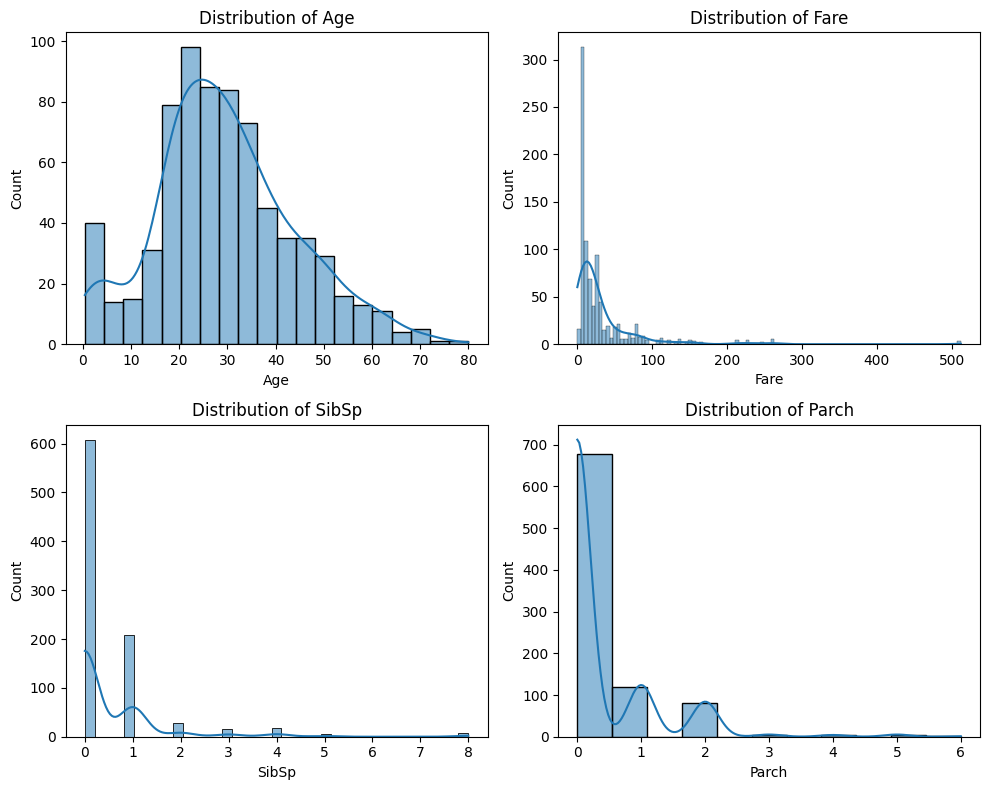

In [85]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

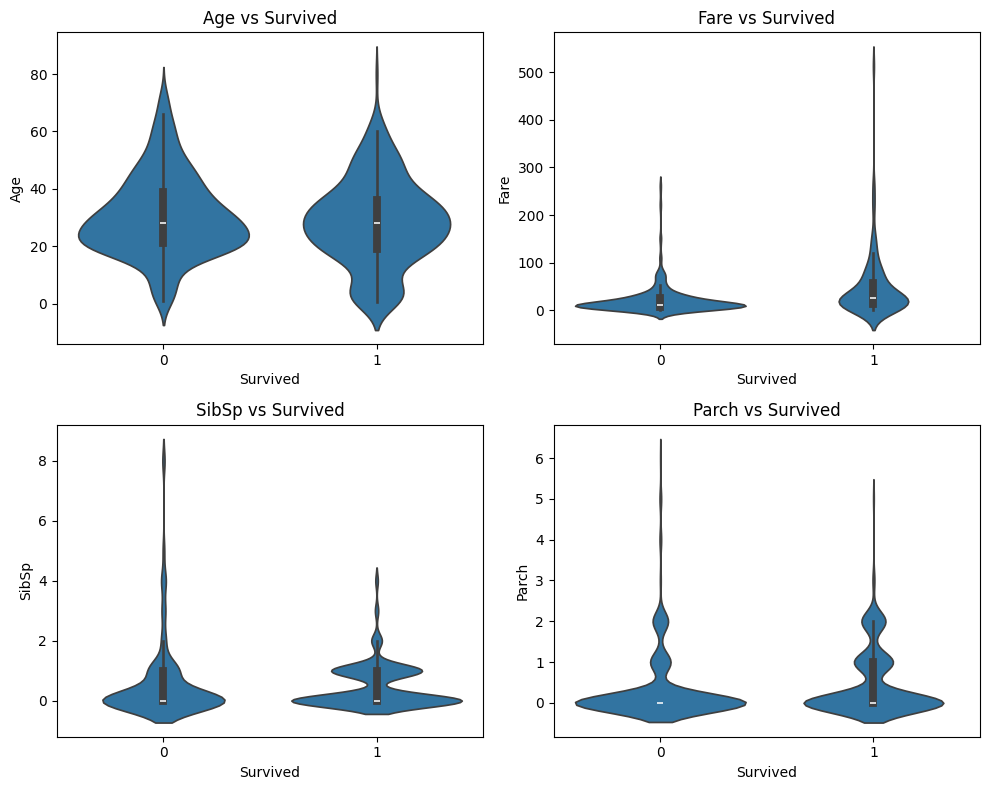

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.violinplot(data=df, x="Survived", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Survived")

plt.tight_layout()
plt.show()

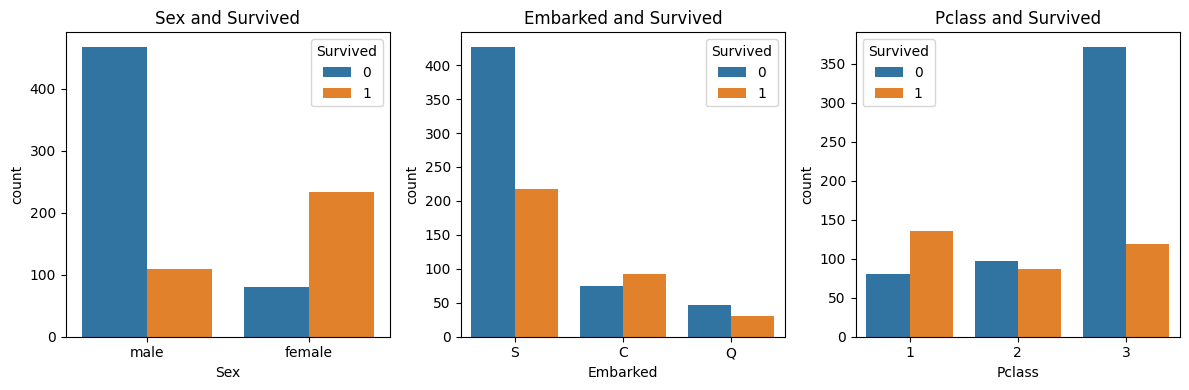

In [87]:
categorical_features = ['Sex', 'Embarked', 'Pclass']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue='Survived', ax=axes[i])
    axes[i].set_title(f"{col} and Survived")

plt.tight_layout()
plt.show()

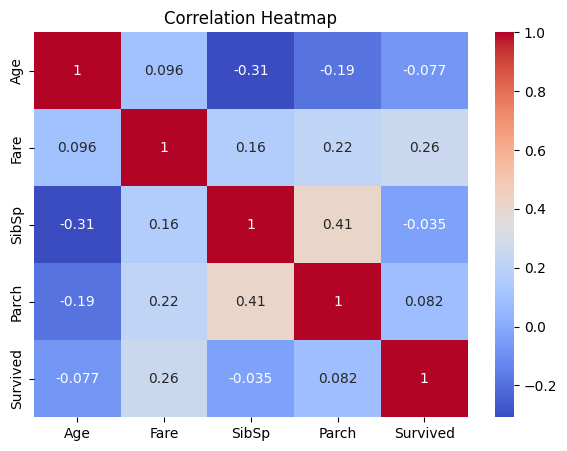

In [88]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_features + ["Survived"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Observations from typical Titanic data:

- Cabin often has a lot of missing values.
- Age is missing in many rows.
- Women (Sex = female) survived at higher rates than men.
- First class passengers (Pclass=1) have higher survival rates.
- There may be some outliers in Fare.

# Data Processing

In [89]:
# TARGET VARIABLE
TARGET_COL = "Survived"

In [90]:
drop_cols = ["PassengerId", "Cabin", "Name", "Ticket"]  # Example approach
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

In [91]:
y = df[TARGET_COL].copy()
X = df.drop(columns=[TARGET_COL]).copy()

In [92]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()  # e.g., Age, Fare, Pclass, SibSp, Parch
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()  # e.g., Sex, Embarked

## Define multiple pipelines

In [93]:
pipelines = {}

### SimpleImputer (mean) + OneHotEncoder

In [94]:
numeric_transformer_a = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())  # optional scaling
])
categorical_transformer_a = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_a = ColumnTransformer([
    ("num", numeric_transformer_a, numeric_features),
    ("cat", categorical_transformer_a, categorical_features)
])
pipeline_a = Pipeline([
    ("preprocessor", preprocessor_a)
])
pipelines["simple_mean_onehot"] = pipeline_a

### KNNImputer + OneHotEncoder

In [95]:
numeric_transformer_b = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])
categorical_transformer_b = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_b = ColumnTransformer([
    ("num", numeric_transformer_b, numeric_features),
    ("cat", categorical_transformer_b, categorical_features)
])
pipeline_b = Pipeline([
    ("preprocessor", preprocessor_b)
])
pipelines["knn_imputer_onehot"] = pipeline_b

### IterativeImputer (with a RandomForestRegressor) + OneHotEncoder
This attempts to predict missing numeric values using all the other features

In [96]:
numeric_transformer_c = Pipeline([
    ("imputer", IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=50, random_state=42),
        max_iter=10,
        random_state=42
    )),
    ("scaler", StandardScaler())
])
categorical_transformer_c = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_c = ColumnTransformer([
    ("num", numeric_transformer_c, numeric_features),
    ("cat", categorical_transformer_c, categorical_features)
])
pipeline_c = Pipeline([
    ("preprocessor", preprocessor_c)
])
pipelines["iterative_rf_onehot"] = pipeline_c


### IterativeImputer + OrdinalEncoder
Some prefer ordinal encoding for categories like Pclass or to reduce dimensionality.

In [97]:
numeric_transformer_d = Pipeline([
    ("imputer", IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=50, random_state=42),
        max_iter=10,
        random_state=42
    )),
    ("scaler", StandardScaler())
])
categorical_transformer_d = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder())  # ordinal encoding
])
preprocessor_d = ColumnTransformer([
    ("num", numeric_transformer_d, numeric_features),
    ("cat", categorical_transformer_d, categorical_features)
])
pipeline_d = Pipeline([
    ("preprocessor", preprocessor_d)
])
pipelines["iterative_rf_ordinal"] = pipeline_d

## FIT EACH PIPELINE, TRANSFORM DATA, SAVE PIPELINE & PROCESSED DATA

In [98]:
for name, pipe in pipelines.items():
    # Fit pipeline on the entire dataset (since we're not training a model yet)
    pipe.fit(X, y)  # For certain imputers (like IterativeImputer) the target may not be used, but that's okay

    # Transform data
    X_transformed = pipe.transform(X)

    # Convert transformed data into a DataFrame
    #   -> We need to reconstruct column names if using OneHotEncoder
    #   -> For ColumnTransformer, we can access transformers to see what happened.
    #   -> Easiest approach: get category names for the OneHotEncoder steps, etc.

    # We'll build a list of feature names step by step
    final_col_names = []

    # 1) Numeric columns
    #    We have the same number of numeric columns after scaling/imputation
    #    So we keep the original numeric_features names
    num_pipeline = pipe.named_steps["preprocessor"].named_transformers_["num"]
    num_col_names = numeric_features  # same length
    # (You could add suffixes like "_scaled" if you want.)
    final_col_names.extend(num_col_names)

    # 2) Categorical columns
    cat_pipeline = pipe.named_steps["preprocessor"].named_transformers_["cat"]
    encoder_step = cat_pipeline.named_steps.get("encoder", None)

    # If we have OneHotEncoder
    if isinstance(encoder_step, OneHotEncoder):
        # get_feature_names_out returns something like ["Sex_female", "Sex_male", "Embarked_S", ...]
        # We supply the original column names to track them properly
        ohe_feature_names = encoder_step.get_feature_names_out(categorical_features)
        final_col_names.extend(ohe_feature_names)
    # If we have OrdinalEncoder
    elif isinstance(encoder_step, OrdinalEncoder):
        # We still just have the same categorical columns, but now numeric
        final_col_names.extend(categorical_features)
    else:
        # Fallback if there's no recognized encoder step
        final_col_names.extend(categorical_features)

    # Ensure the number of columns match
    if X_transformed.shape[1] != len(final_col_names):
        print(f"Warning: mismatch in column count for pipeline {name}")

    # Create a DataFrame for the transformed data
    df_transformed = pd.DataFrame(X_transformed, columns=final_col_names)

    # Optionally, re-attach the target for clarity
    df_transformed[TARGET_COL] = y.values

    # SAVE THE PIPELINE

    destination_path = f'processed_data/{name}'
    os.mkdir(destination_path)

    pipeline_path = f"{destination_path}/{name}_pipeline.joblib"
    joblib.dump(pipe, pipeline_path)

    # SAVE THE TRANSFORMED DATA
    data_path = f"{destination_path}/{name}_processed.csv"
    df_transformed.to_csv(data_path, index=False)

    print(f"Pipeline '{name}' fitted and saved. Transformed data saved to '{data_path}'.")

Pipeline 'simple_mean_onehot' fitted and saved. Transformed data saved to 'processed_data/simple_mean_onehot/simple_mean_onehot_processed.csv'.
Pipeline 'knn_imputer_onehot' fitted and saved. Transformed data saved to 'processed_data/knn_imputer_onehot/knn_imputer_onehot_processed.csv'.
Pipeline 'iterative_rf_onehot' fitted and saved. Transformed data saved to 'processed_data/iterative_rf_onehot/iterative_rf_onehot_processed.csv'.
Pipeline 'iterative_rf_ordinal' fitted and saved. Transformed data saved to 'processed_data/iterative_rf_ordinal/iterative_rf_ordinal_processed.csv'.


# Model Training

In [99]:
import os
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
def load_and_split_data(filepath, target_col="Survived", test_size=0.2, random_state=42):
    """
    Loads a CSV, splits into train/test sets,
    returns X_train, X_test, y_train, y_test.
    """
    df = pd.read_csv(filepath)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

In [101]:
DATASET_PATHS = {
    "simple_mean_onehot": "/content/processed_data/simple_mean_onehot/simple_mean_onehot_processed.csv",
    "knn_imputer_onehot": "/content/processed_data/knn_imputer_onehot/knn_imputer_onehot_processed.csv",
    "iterative_rf_ordinal": "/content/processed_data/iterative_rf_ordinal/iterative_rf_ordinal_processed.csv"
}

In [102]:
models_and_params = {
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"],
            "p": [1, 2]
        }
    ),
    "LogisticRegression": (
        LogisticRegression(solver="liblinear", max_iter=100),
        {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l1", "l2"]
        }
    )
}

In [103]:
all_results = []

for ds_name, ds_path in DATASET_PATHS.items():
    print(f"\n=== Dataset: {ds_name} ===")

    X_train, X_test, y_train, y_test = load_and_split_data(ds_path)

    for model_name, (model_obj, param_grid) in models_and_params.items():

        print(f"\n--- Model: {model_name} ---")

        grid_search = GridSearchCV(
            estimator=model_obj,
            param_grid=param_grid,
            scoring="accuracy",       # or "f1", or multiple
            cv=5,                     # 5-fold cross-validation
            verbose=2,               # set to 2 for more logs
            n_jobs=-1                # parallel jobs
        )
        grid_search.fit(X_train, y_train)

        # Extract best model
        best_model = grid_search.best_estimator_

        # Predict
        y_pred = best_model.predict(X_test)

        # Evaluate
        acc = best_model.score(X_test, y_test)
        auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]) if model_name == "LogisticRegression" or model_name == "KNN" else None
        clf_report = classification_report(y_test, y_pred, output_dict=True)
        conf_mat = confusion_matrix(y_test, y_pred)

        # Print textual summary
        print(f"Best Params: {grid_search.best_params_}")
        print(f"Test Accuracy: {acc:.4f}")
        print(f"Test ROC-AUC: {auc:.4f}" if auc is not None else "Test ROC-AUC: N/A (didn't compute probability)")
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        print("Confusion Matrix:")
        print(conf_mat)

        # Store in results list
        all_results.append({
            "dataset": ds_name,
            "model": model_name,
            "best_params": grid_search.best_params_,
            "accuracy": acc,
            "roc_auc": auc,
            "classification_report": clf_report,
            "conf_matrix": conf_mat
        })


=== Dataset: simple_mean_onehot ===

--- Model: KNN ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}
Test Accuracy: 0.8101
Test ROC-AUC: 0.8569
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix:
[[97 13]
 [21 48]]

--- Model: LogisticRegression ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'C': 0.1, 'penalty': 'l2'}
Test Accuracy: 0.7933
Test ROC-AUC: 0.8466
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy            

In [104]:
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df[[
    "dataset",
    "model",
    "best_params",
    "accuracy",
    "roc_auc"
]].sort_values(by=["accuracy", "roc_auc"], ascending=False)

print("\n=== Overall Comparison ===")
print(comparison_df)


=== Overall Comparison ===
                dataset               model  \
0    simple_mean_onehot                 KNN   
3    knn_imputer_onehot  LogisticRegression   
4  iterative_rf_ordinal                 KNN   
2    knn_imputer_onehot                 KNN   
5  iterative_rf_ordinal  LogisticRegression   
1    simple_mean_onehot  LogisticRegression   

                                        best_params  accuracy   roc_auc  
0  {'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}  0.810056  0.856917  
3                       {'C': 0.1, 'penalty': 'l2'}  0.804469  0.842161  
4  {'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}  0.798883  0.843742  
2  {'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}  0.798883  0.836891  
5                       {'C': 0.1, 'penalty': 'l2'}  0.793296  0.853491  
1                       {'C': 0.1, 'penalty': 'l2'}  0.793296  0.846640  


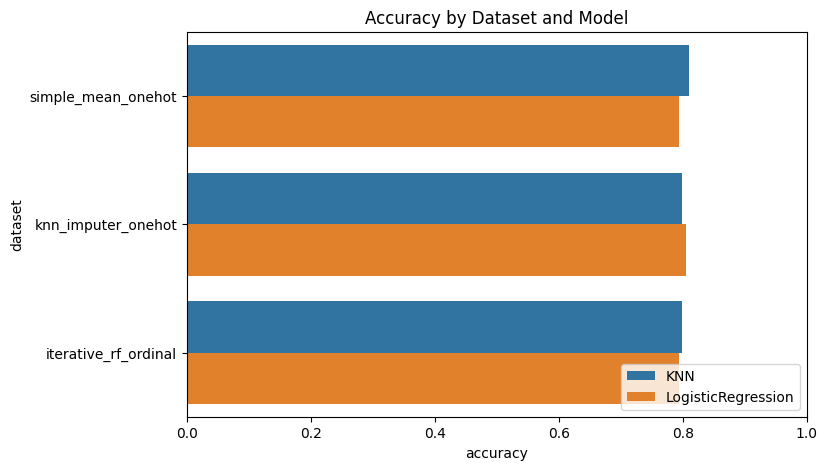

In [105]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=comparison_df,
    x="accuracy",
    y="dataset",
    hue="model"
)
plt.title("Accuracy by Dataset and Model")
plt.xlim(0, 1)
plt.legend(loc="lower right")
plt.show()

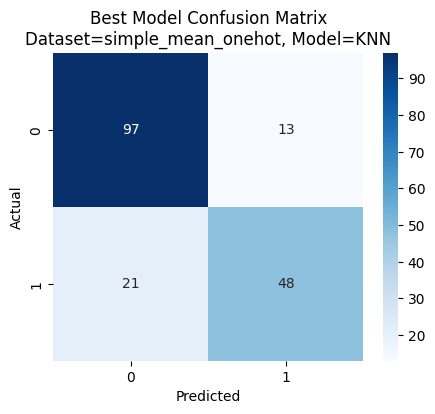

In [106]:
best_row = comparison_df.iloc[0]  # top row
best_dataset = best_row["dataset"]
best_model_name = best_row["model"]

# We find the exact entry in all_results that matches
best_result = next(
    item for item in all_results
    if item["dataset"] == best_dataset and item["model"] == best_model_name
       and item["accuracy"] == best_row["accuracy"]
)
best_conf_mat = best_result["conf_matrix"]

plt.figure(figsize=(5, 4))
sns.heatmap(best_conf_mat, annot=True, fmt="d", cmap="Blues")
plt.title(f"Best Model Confusion Matrix\nDataset={best_dataset}, Model={best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Shape of hold-out test data: (891, 11)
Final Hold-out Test Accuracy: 0.8440

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       549
           1       0.82      0.77      0.79       342

    accuracy                           0.84       891
   macro avg       0.84      0.83      0.83       891
weighted avg       0.84      0.84      0.84       891

Confusion Matrix:
 [[490  59]
 [ 80 262]]


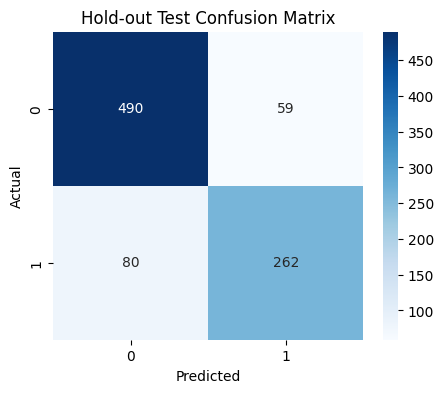

In [107]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

df_test = pd.read_csv("/content/processed_data/knn_imputer_onehot/knn_imputer_onehot_processed.csv")
print("Shape of hold-out test data:", df_test.shape)

# 2) Separate features and target
TARGET_COL = "Survived"
X_test_final = df_test.drop(columns=[TARGET_COL])
y_test_final = df_test[TARGET_COL]

# 3) Load your best pipeline (this pipeline should contain both the preprocessor and the trained classifier)
best_pipeline = joblib.load("/content/processed_data/knn_imputer_onehot/knn_imputer_onehot_pipeline.joblib")

model = KNeighborsClassifier(n_neighbors=7, weights='uniform', p=2)

model.fit(X_test_final, y_test_final)

# 4) Predict on hold-out test data
y_pred_final = model.predict(X_test_final)


# 5) Evaluate
acc_final = accuracy_score(y_test_final, y_pred_final)

print(f"Final Hold-out Test Accuracy: {acc_final:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_final))

# 6) Confusion Matrix
conf_mat_final = confusion_matrix(y_test_final, y_pred_final)
print("Confusion Matrix:\n", conf_mat_final)

# 7) Optional: Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat_final, annot=True, fmt="d", cmap="Blues")
plt.title("Hold-out Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
